# BASELINE VALIDATAION (DELANEY DATASET)
Establishing a proof-of-concept environment by predicting basic physical properties (solubility) using a small dataset and a Random Forest Regressor.

In [2]:
import ssl
import os

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context



In [3]:
import deepchem as dc
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

# 1. Download the 'delaney' dataset (a classic drug solubility dataset)
# This includes SMILES strings and their measured properties.
tasks, datasets, transformers = dc.molnet.load_delaney(featurizer='ECFP')
train_dataset, valid_dataset, test_dataset = datasets

# 2. Convert the dataset to a Pandas DataFrame so we can actually see it
df = train_dataset.to_dataframe()

# 3. Clean up the column names for better readability
# 'ids' contains the SMILES strings (the text version of the molecule)
# 'y' contains the solubility score
df = df[['ids', 'y']]
df.columns = ['SMILES', 'Solubility_Score']

print(f"✅ Dataset Loaded! Total molecules: {len(df)}")
print(df.head())

[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerator
[12:26:19] DEPRECATION WARNING: please use MorganGenerat

✅ Dataset Loaded! Total molecules: 902
                 SMILES  Solubility_Score
0  CC(C)=CCCC(C)=CC(=O)          0.390413
1                CCCC=C          0.090421
2        CCCCCCCCCCCCCC         -2.464346
3               CC(C)Cl          0.704920
4              CCC(C)CO          1.159746


In [4]:
from rdkit.Chem import Descriptors

def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return pd.Series({
            'MolWeight': Descriptors.MolWt(mol),
            'LogP': Descriptors.MolLogP(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol)
        })
    else:
        return pd.Series([None]*4)

# Apply the function to the dataframe
properties_df = df['SMILES'].apply(calculate_descriptors)
df = pd.concat([df, properties_df], axis=1)

print("✅ Properties Calculated!")
print(df.head())

✅ Properties Calculated!
                 SMILES  Solubility_Score  MolWeight    LogP  NumHDonors  \
0  CC(C)=CCCC(C)=CC(=O)          0.390413    152.237  2.8780         0.0   
1                CCCC=C          0.090421     70.135  1.9725         0.0   
2        CCCCCCCCCCCCCC         -2.464346    198.394  5.7074         0.0   
3               CC(C)Cl          0.704920     78.542  1.6336         0.0   
4              CCC(C)CO          1.159746     88.150  1.0248         1.0   

   NumHAcceptors  
0            1.0  
1            0.0  
2            0.0  
3            0.0  
4            1.0  


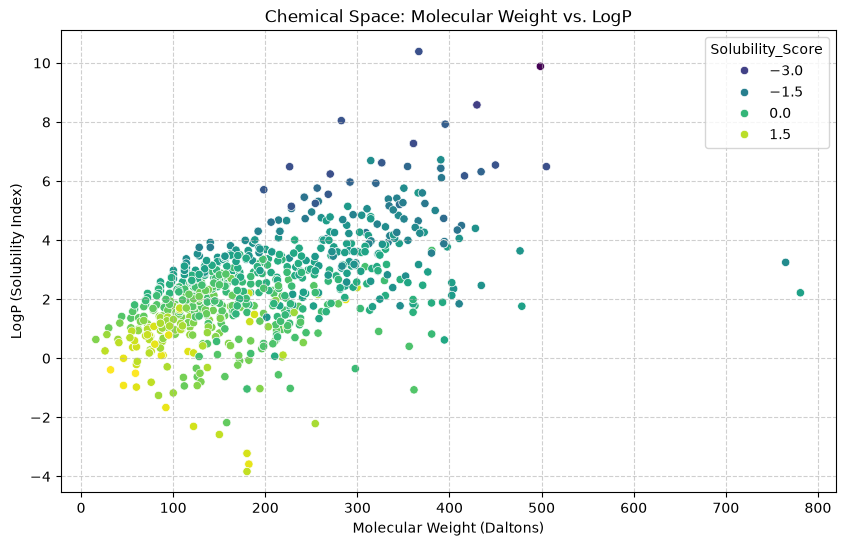

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MolWeight', y='LogP', hue='Solubility_Score', palette='viridis')

plt.title('Chemical Space: Molecular Weight vs. LogP')
plt.xlabel('Molecular Weight (Daltons)')
plt.ylabel('LogP (Solubility Index)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Prepare the Data
# We use the features we calculated (Weight, LogP, etc.) to predict Solubility_Score
features = ['MolWeight', 'LogP', 'NumHDonors', 'NumHAcceptors']
X = df[features].dropna()
y = df.loc[X.index, 'Solubility_Score']

# 2. Split into Training (80%) and Testing (20%) sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make Predictions
predictions = model.predict(X_test)

# 5. Evaluate the 'Accuracy'
r2 = r2_score(y_test, predictions)
print(f"✅ Model Trained! R-squared Score: {r2:.2f}")


✅ Model Trained! R-squared Score: 0.86


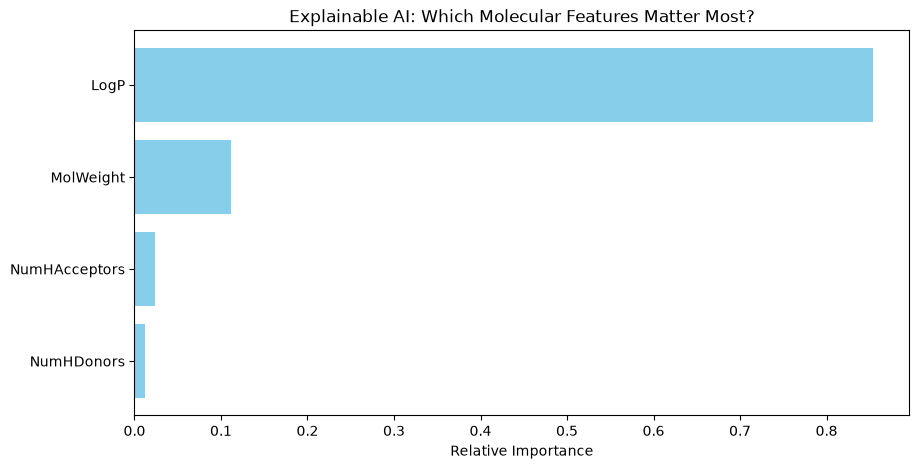

In [7]:
import numpy as np

# Get importance levels from the model
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.title('Explainable AI: Which Molecular Features Matter Most?')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()